In [1]:
import os
import nsbi_common_utils
import pandas as pd
import numpy as np
import mplhep as hep
import pickle
import matplotlib.pyplot as plt
from nsbi_common_utils.training.utils import load_trained_model
import pprint

In [2]:
BASE_PATH = "./dataframes/"

In [3]:
signal = pd.read_parquet(f"{BASE_PATH}/signal.parquet")
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

# Summary statistics

We will start by doing a traditional binned SBI

We will compare two binned analysis: one using a one-dimensional ($x_1$) and one using a two-dimensional observable ($x_1,x_2$).

In [4]:
def hist_template(values, edges, weights):
    values_clipped = np.clip(values, edges[0], edges[-1])
    hist, _ = np.histogram(values_clipped, bins=edges, weights=weights)
    return hist

var = 'x1'
bins = np.linspace(-3,8,12)

signal_weights = np.array(signal.weight)
background_weights = np.array(background.weight)

h_sig = hist_template(signal[var], bins, signal_weights)
h_bkg = hist_template(background[var], bins, background_weights)

def hist_template_2d(x_vals, y_vals, x_edges, y_edges, weights):
 
    x_clipped = np.clip(x_vals, x_edges[0], x_edges[-1])
    y_clipped = np.clip(y_vals, y_edges[0], y_edges[-1])

    h2d, _, _ = np.histogram2d(
        x_clipped,
        y_clipped,
        bins=[x_edges, y_edges],
        weights=weights
    )

    return h2d

xvar = "x1"
yvar = "x2"
h2d_sig = hist_template_2d(signal[xvar], signal[yvar], bins, bins, signal_weights)
h2d_bkg = hist_template_2d(background[xvar], background[yvar], bins, bins, background_weights)

# Visualizing the statistics

Both summary statistics can be used to perform inference, but neither are sufficient.

Plotting can be a powerful way to show to which degree an inference on the signal strength can be performed.

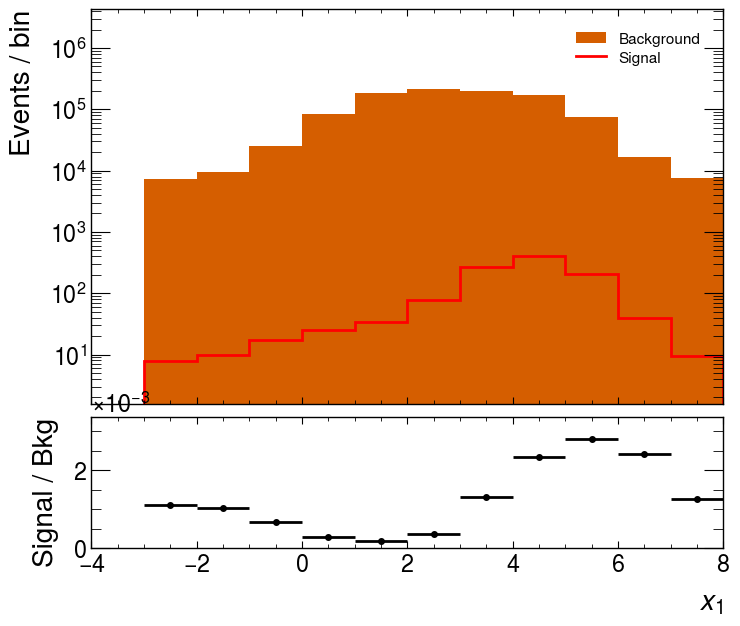

In [34]:
def plot_histograms(signal_yield_per_bin, background_yield_per_bin, bins, log_y=False, ax_title=r"$x_1$"):
    fig, (ax, rax) = plt.subplots(
        2, 1,
        figsize=(8.0, 7.0),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )

    # Background drawn as a filled stack (a list, so more backgrounds can be
    # added later). Signal is overlaid UNSTACKED as a step line -- with a true
    # S/B ~ 1e-3 a stacked signal would be an invisible sliver on top.
    hep.histplot(
        [background_yield_per_bin],
        bins=bins,
        stack=True,
        histtype="fill",
        label=["Background"],
        ax=ax,
    )
    hep.histplot(
        signal_yield_per_bin,
        bins=bins,
        histtype="step",
        lw=2,
        color="red",
        label="Signal",
        ax=ax,
    )

    centers = 0.5 * (bins[1:] + bins[:-1])
    half_widths = 0.5 * np.diff(bins)

    observation_per_bin = signal_yield_per_bin + background_yield_per_bin
    obs_err = np.sqrt(np.maximum(observation_per_bin, 0.0))

    # Ratio panel: signal / background, with sqrt(obs) propagated as the error.
    prediction = background_yield_per_bin
    ratio = np.divide(
        signal_yield_per_bin, prediction,
        out=np.full_like(observation_per_bin, np.nan, dtype=float),
        where=prediction > 0,
    )
    ratio_err = np.divide(
        obs_err, prediction,
        out=np.full_like(obs_err, np.nan, dtype=float),
        where=prediction > 0,
    )

    rax.errorbar(
        centers, ratio,
        xerr=half_widths, yerr=0,
        fmt="o", markersize=4, color="black",
    )
    # Auto-scale the ratio panel to the finite points (fixed 0-10 hides a ~1e-3 ratio).
    finite = ratio[np.isfinite(ratio)]
    if finite.size:
        rax.set_ylim(0.0, 1.2 * finite.max())

    ax.set_ylabel("Events / bin")
    rax.set_ylabel("Signal / Bkg")
    rax.set_xlabel(ax_title)
    ax.legend(fontsize=11)

    if log_y:
        positive = np.concatenate([background_yield_per_bin, signal_yield_per_bin])
        positive = positive[positive > 0]
        if positive.size:
            ax.set_yscale("log")
            ax.set_ylim(max(positive.min() * 0.2, 1.0e-3), positive.max() * 20.0)
    else:
        ymax = max(
            np.max(background_yield_per_bin) if background_yield_per_bin.size else 0.0,
            np.max(signal_yield_per_bin) if signal_yield_per_bin.size else 0.0,
            np.max(observation_per_bin + obs_err) if observation_per_bin.size else 0.0,
        )
        ax.set_ylim(0.0, ymax if ymax > 0 else 1.0)


plot_histograms(h_sig, h_bkg, bins, log_y=True)


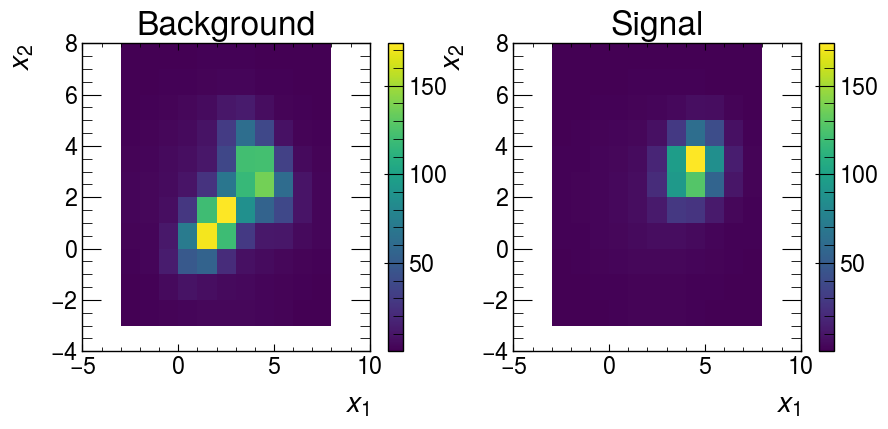

In [6]:
def plot_histograms_2d(signal_yield_per_bin, background_yield_per_bin, bins):

    fig, axs = plt.subplots(1,2,figsize=(10.0, 4.0))

    mesh = axs[0].pcolormesh(
        bins,
        bins,
        background_yield_per_bin.T, 
    )
    mesh = axs[1].pcolormesh(
        bins,
        bins,
        signal_yield_per_bin.T, 
    )

    fig.colorbar(mesh, ax=axs[0])
    fig.colorbar(mesh, ax=axs[1])
    axs[0].set_title('Background')
    axs[1].set_title('Signal')

    for ax in axs:
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
plot_histograms_2d(h2d_sig,h2d_bkg,bins)

# Workspaces

Workspaces provide a serialization of the information used to perform inference. 

In [7]:
def make_workspace(signal_yield_per_bin,background_yield_per_bin,observation_yield_per_bin):
    return {"channels": [
        {
            "name": "SR",
            "samples": [
                {
                    "name": "signal",
                    "data": signal_yield_per_bin,
                    "modifiers": [{"name": "mu", "type": "normfactor", "data": None}],
                },
                {
                    "name": "background",
                    "data": background_yield_per_bin,
                    "modifiers": [],
                },
            ],
            "type": "binned",
        }
    ],
    "measurements": [
        {
            "name": "meas",
            "config": {
                "poi": "mu",
                "parameters": [
                    {"bounds": [[-10.0, 10.0]], "inits": [1.0], "name": "mu"},
                ],
            },
        }
    ],
    "version": "1.0.0",
}

ws_x1 = make_workspace((h_sig).tolist(), (h_bkg).tolist(), (h_sig+h_bkg).tolist())
pprint.pprint(ws_x1)

sig_2dyields = h2d_sig.ravel(order="C")
bkg_2dyields = h2d_bkg.ravel(order="C")
ws_x1x2 = make_workspace((sig_2dyields).tolist(), (bkg_2dyields).tolist(), (sig_2dyields+bkg_2dyields).tolist())


{'channels': [{'name': 'SR',
               'samples': [{'data': [7.905039999999957,
                                     9.812879999999915,
                                     17.135579999999855,
                                     25.327059999999747,
                                     34.45970000000892,
                                     76.15102000003756,
                                     264.9004599998687,
                                     407.3036000003182,
                                     207.34692000051962,
                                     40.11458000010066,
                                     9.543160000021317],
                            'modifiers': [{'data': None,
                                           'name': 'mu',
                                           'type': 'normfactor'}],
                            'name': 'signal'},
                           {'data': [7170.20000000006,
                                     9612.79999999964,
             

In [8]:
model_x1 = nsbi_common_utils.models.sbi_parametric_model(workspace=ws_x1, measurement_to_fit="meas")
list_params, init_values = model_x1.get_model_parameters()
num_unconstrained = model_x1.num_unconstrained_param
inf_model_x1 = nsbi_common_utils.inference.inference(
    model_nll=model_x1.model,
    initial_values=init_values,
    list_parameters=list_params,
    num_unconstrained_params=num_unconstrained,
    model_grad=model_x1.model_grad)

In [9]:
print("\n" + "="*40)
print(" MODEL X1 FIT RESULTS ")
print("="*40 + "\n")
inf_model_x1.perform_fit(freeze_params=[])


 MODEL X1 FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.176e+07                 │              Nfcn = 23               │
│ EDM = 1.78e-13 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬───────

In [10]:
scan_points_model_x1, NLL_value_model_x1, scan_points_StatOnly_model_x1, NLL_value_StatOnly_model_x1 = inf_model_x1.perform_profile_scan(parameter_name = 'mu', 
                             freeze_params = [], 
                             bound_range = (0, 3.0), 
                             fit_strategy = 0, 
                             doStatOnly = True,
                             size = 50)

Text(0, 1, '$t_\\mu$')

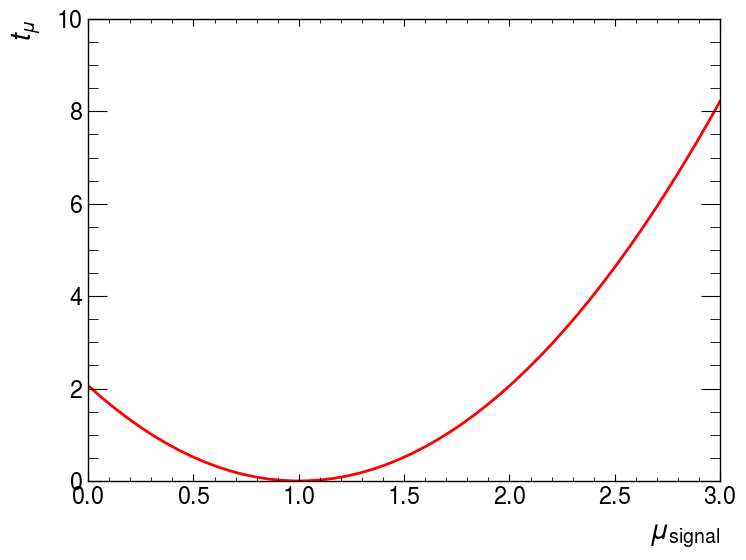

In [11]:
plt.plot(scan_points_model_x1, NLL_value_model_x1, color='red')
plt.axis(ymin=0)
plt.xlabel(r"$\mu_\mathrm{signal}$")
plt.ylabel(r"$t_\mu$")

# Understanding the math

The probability model for each bin is:

\begin{equation}
p_i = \text{Poisson}(N_i|\mu\nu_i^{(S)}+\nu_i^{(B)})=e^{-(\mu\nu_i^{(S)}+\nu_i^{(B)})}(\mu\nu_i^{(S)}+\nu_i^{(B)})^{N_i}, \qquad i=1, \ldots, n_{\text{bins}}
\end{equation}

and

\begin{equation}
p(\mathcal{D})=\prod_{i=1}^{n_{\text{bins}}} p_i
\end{equation}

In [12]:
import jax
import jax.numpy as jnp

def nll_manual(params):
    mu = params[0]
    per_bin = -(mu * h_sig + h_bkg)+(h_sig + h_bkg)*jnp.log(mu * h_sig + h_bkg)
    return -2.0 * jnp.sum(per_bin)


inf_manual = nsbi_common_utils.inference.inference(
    model_nll=jax.jit(nll_manual),
    initial_values=[1.0],
    list_parameters=["mu"],
    num_unconstrained_params=1,
    model_grad=jax.jit(jax.grad(nll_manual)),  # analytic gradient, for free
)
inf_manual.perform_fit(freeze_params=[])

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.176e+07                 │              Nfcn = 23               │
│ EDM = 1.78e-13 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────

# Increasing the dimensionality

A 2D summary statistics will have more information. 

In [13]:
model_x1x2 = nsbi_common_utils.models.sbi_parametric_model(workspace=ws_x1x2, measurement_to_fit="meas")
list_params, init_values = model_x1x2.get_model_parameters()
num_unconstrained = model_x1x2.num_unconstrained_param
inf_model_x1x2 = nsbi_common_utils.inference.inference(
    model_nll=model_x1x2.model,
    initial_values=init_values,
    list_parameters=list_params,
    num_unconstrained_params=num_unconstrained,
    model_grad=model_x1x2.model_grad)

In [14]:
print("\n" + "="*40)
print(" MODEL X1-X2 FIT RESULTS ")
print("="*40 + "\n")
inf_model_x1x2.perform_fit(freeze_params=[])


 MODEL X1-X2 FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.837e+07                 │              Nfcn = 25               │
│ EDM = 1.03e-12 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────

In [15]:
scan_points_model_x1x2, NLL_value_model_x1x2, scan_points_StatOnly_model_x1x2, NLL_value_StatOnly_model_x1x2 = inf_model_x1x2.perform_profile_scan(parameter_name = 'mu', 
                             freeze_params = [], 
                             bound_range = (0, 3.0), 
                             fit_strategy = 0, 
                             doStatOnly = True,
                             size = 50)

Text(0, 1, '$t_\\mu$')

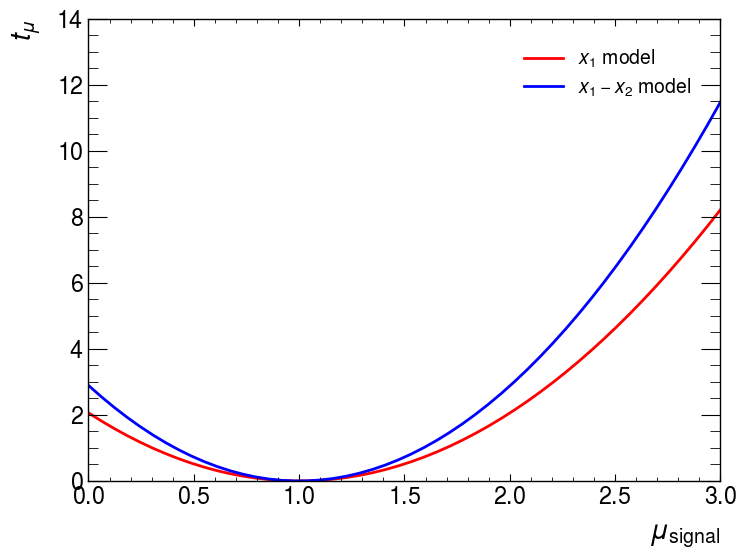

In [16]:
plt.plot(scan_points_model_x1, NLL_value_model_x1, label=r'$x_1$ model', color='red')
plt.plot(scan_points_model_x1x2, NLL_value_model_x1x2, label=r'$x_1-x_2$ model', color='blue')
plt.axis(ymin=0)
plt.legend()
plt.xlabel(r"$\mu_\mathrm{signal}$")
plt.ylabel(r"$t_\mu$")

# A sufficient statistics

\begin{equation}
p(x;\mu) = \frac{1}{\mu\nu_S+\nu_B} \left[\mu \nu_S p_S(x) + \nu_B p_B(x)\right] = p_B(x) \times \frac{1}{\mu\,\nu_S/\nu_B+1} \times \left[ \mu \frac{\nu_S}{\nu_B} \frac{p_S(x)}{p_B(x)} + 1 \right] 
\end{equation}

$p_S(x)/p_B(x)$ is a sufficient statistics and can be approximated by a NN

In [17]:
from utils import split_train_inference

SPLIT_SEED = 0
TRAIN_FRACTION = 0.5  # fraction of each sample used for TRAINING

signal, _ = split_train_inference(signal, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED)
background, _ = split_train_inference(background, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED)

print(f"Training on {len(signal):,} signal + {len(background):,} background events")

Training on 2,500,000 signal + 2,500,000 background events


In [18]:
training_features = ["x1", "x2", "x3", "x4", "x5"]

In [19]:
numerator_hypothesis = signal.astype('float32').copy()
denominator_hypothesis = background.astype('float32').copy()

In [20]:
numerator_hypothesis["weights"] = numerator_hypothesis['weight']
numerator_hypothesis["weights_normed"] = numerator_hypothesis['weight'] / numerator_hypothesis['weight'].sum()
numerator_hypothesis["train_labels"] = 1.0

denominator_hypothesis["weights"] = denominator_hypothesis['weight']
denominator_hypothesis["weights_normed"] = denominator_hypothesis['weight'] / denominator_hypothesis['weight'].sum()
denominator_hypothesis["train_labels"] = 0.0

In [21]:
N_TRAIN = 1_500_000  # None = use all events

training_dataframe = pd.concat([numerator_hypothesis, denominator_hypothesis], ignore_index=True)
training_dataframe = training_dataframe.sample(frac=1, random_state=42, ignore_index=True)

if N_TRAIN is not None:
    training_dataframe = training_dataframe.head(N_TRAIN).reset_index(drop=True)
    # Re-normalize per-class weights so each class still sums to 1 after subsetting
    for label_val in [0.0, 1.0]:
        mask = training_dataframe["train_labels"] == label_val
        training_dataframe.loc[mask, "weights_normed"] = (
            training_dataframe.loc[mask, "weight"]
            / training_dataframe.loc[mask, "weight"].sum()
        )

In [22]:
ensemble_size = 1

In [23]:
from nsbi_common_utils.training import density_ratio_trainer

trainer = [None for i in range(ensemble_size)]

for ens_index in range(ensemble_size):
    trainer[ens_index] = density_ratio_trainer(
        dataset=training_dataframe,
        weights=training_dataframe["weights_normed"],
        training_labels=training_dataframe["train_labels"],
        features=training_features,
        features_scaling=training_features,
        sample_name=["signal", "reference"],
        output_name="",
        path_to_figures="plots_SigvsBkg/",
        path_to_models="models_SigvsBkg/",
    )

In [24]:
for ens_index in range(ensemble_size):

    trainer[ens_index].train(
        hidden_layers=3,
        neurons=1024,
        number_of_epochs=5,
        batch_size=4096,
        learning_rate=1e-3,
        scalerType="MinMax",
        ensemble_index=ens_index,
        verbose=1,
        holdout_split=0.25, # validation
        validation_split=0.2,
        callback_patience=10,
        num_workers=4,
        load_trained_models=False,
        calibration=False,
        type_of_calibration = "histogram",
        recalibrate_output=True,
        num_bins_cal = 50
    )

2026-07-06 03:15:05 | INFO | Training Logs | Sum of weights of class 0: 0.7500003336390364
2026-07-06 03:15:05 | INFO | Training Logs | Sum of weights of class 1: 0.7499995909083736
2026-07-06 03:15:05 | INFO | Training Logs | Using swish activation function
2026-07-06 03:15:05 | INFO | Training Logs | Setting log loss to False
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: 

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  2.1 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 8.425                                                                      
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch    0 | lr = 1.000e-03 | val_loss = 0.693172 | 


...

[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
2026-07-06 03:18:49 | INFO | Training Logs | reference training data has min ratio 0.0012836820678785443
2026-07-06 03:18:49 | INFO | Training Logs | reference training data has max ratio 97.07222747802734
2026-07-06 03:18:49 | INFO | Training Logs | signal training data has min ratio 0.0013611041940748692
2026-07-06 03:18:49 | INFO | Training Logs | signal training data has max ratio 123.12947845458984
2026-07-06 03:18:49 | INFO | Training Logs | reference holdout data has min ratio 0.001278273994103074
2026-07-06 03:18:49 | INFO | Training Logs | reference holdout data has max ratio 96.95541381835938
2026-07-06 03:18:49 | INFO | Tr

<Figure size 800x600 with 0 Axes>

In [ ]:
sig_ratios = []
bkg_ratios = []
for ens_index in range(ensemble_size):
    path_to_saved_scaler = f"models_SigvsBkg/model_scaler{ens_index}.bin"
    path_to_saved_model  = f"models_SigvsBkg/model{ens_index}.onnx"

    scaler, model = load_trained_model(path_to_saved_model, path_to_saved_scaler)

    signal_ratio = nsbi_common_utils.training.utils.predict_with_model(
        signal[training_features].astype('float32'),
        scaler=scaler,
        model=model,
    )
    background_ratio = nsbi_common_utils.training.utils.predict_with_model(
        background[training_features].astype('float32'),
        scaler=scaler,
        model=model,
    )
    sig_ratios.append(signal_ratio)
    bkg_ratios.append(background_ratio)

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


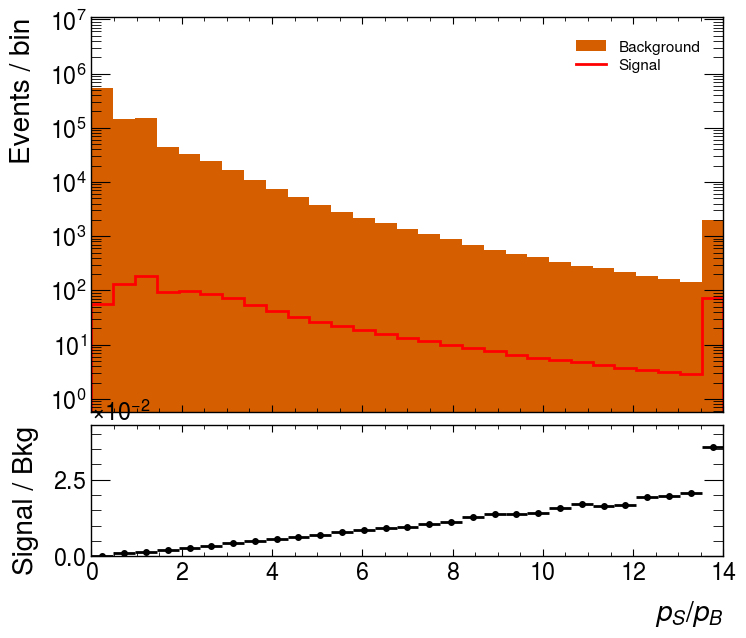

In [ ]:
bins_ratio = np.linspace(0,14,30)
h_sig_ratio = hist_template(sig_ratios[0], bins_ratio, signal["weight"])
h_bkg_ratio = hist_template(bkg_ratios[0], bins_ratio, background["weight"])
plot_histograms(h_sig_ratio,h_bkg_ratio,bins_ratio, True, r'$p_S/p_B$')

In [46]:
ws_ratio = make_workspace((h_sig_ratio).tolist(), (h_bkg_ratio).tolist(), (h_sig_ratio+h_bkg_ratio).tolist())
model_ratio = nsbi_common_utils.models.sbi_parametric_model(workspace=ws_ratio, measurement_to_fit="meas")
list_params, init_values = model_ratio.get_model_parameters()
num_unconstrained = model_ratio.num_unconstrained_param
inf_model_ratio = nsbi_common_utils.inference.inference(
    model_nll=model_ratio.model,
    initial_values=init_values,
    list_parameters=list_params,
    num_unconstrained_params=num_unconstrained,
    model_grad=model_ratio.model_grad)

In [47]:
print("\n" + "="*40)
print(" MODEL pS/pB FIT RESULTS ")
print("="*40 + "\n")
inf_model_ratio.perform_fit(freeze_params=[])


 MODEL pS/pB FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.257e+07                 │              Nfcn = 20               │
│ EDM = 7.53e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────

In [48]:
scan_points_model_ratio, NLL_value_model_ratio, scan_points_StatOnly_model_ratio, NLL_value_StatOnly_model_ratio = inf_model_ratio.perform_profile_scan(parameter_name = 'mu', 
                             freeze_params = [], 
                             bound_range = (0, 3.0), 
                             fit_strategy = 0, 
                             doStatOnly = True,
                             size = 50)

Text(0, 1, '$t_\\mu$')

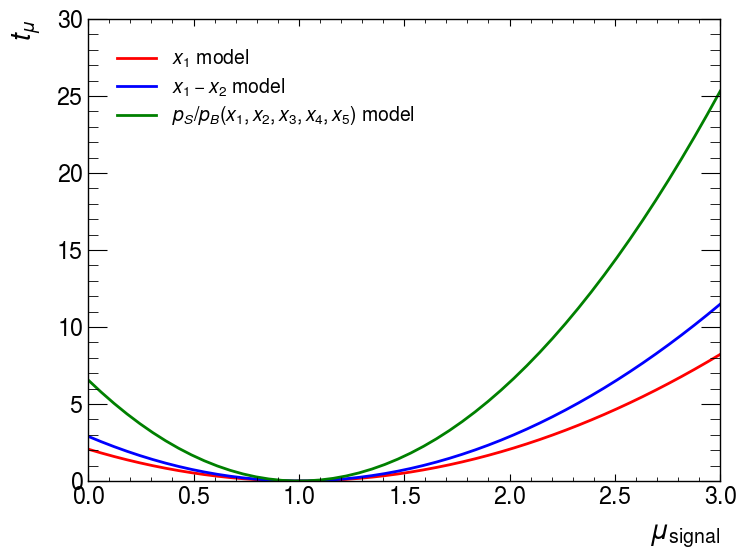

In [49]:
plt.plot(scan_points_model_x1, NLL_value_model_x1, label=r'$x_1$ model', color='red')
plt.plot(scan_points_model_x1x2, NLL_value_model_x1x2, label=r'$x_1-x_2$ model', color='blue')
plt.plot(scan_points_model_ratio, NLL_value_model_ratio, label=r'$p_S/p_B (x_1,x_2,x_3,x_4,x_5)$ model', color='green')
plt.axis(ymin=0)
plt.legend()
plt.xlabel(r"$\mu_\mathrm{signal}$")
plt.ylabel(r"$t_\mu$")